# Fairness Evaluation and Bias Mitigation in Machine Learning

## Overview

This notebook studies fairness issues in an income prediction model.

The experiments include:

- Group fairness metrics
- Demographic parity analysis
- Equal opportunity evaluation
- MinDiff-style bias mitigation
- Group-specific threshold optimization

The goal is to analyze and improve model fairness while studying the trade-off between fairness and predictive performance.

## Experiment Setup

Dataset:
- ACS Income Dataset

Task:
- Binary income classification (>50K income prediction)

Model:
- Multi-layer Perceptron (MLP)

Sensitive Attribute:
- Sex (Male/Female)

Fairness Methods:
1. In-processing:
   - MinDiff-style MMD regularization

2. Post-processing:
   - Group-specific threshold optimization

## Setup

No package installation is required in standard Colab. If you run this on Kaggle, make sure internet is enabled for the dataset download, or upload the CSV and set `LOCAL_DATA_PATH`.

In [1]:
import random

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 200
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
plt.style.use("seaborn-v0_8-whitegrid")

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

PyTorch: 2.11.0+cpu
Device: cpu


## Load Data

We read the prepared ACSIncome CSV directly to avoid extra dataset packages. If the download is blocked, upload `acsincome_raw_2018.csv` and set `LOCAL_DATA_PATH`.

In [2]:
DATA_URL = "https://download.mlcc.google.com/mledu-datasets/acsincome_raw_2018.csv"
LOCAL_DATA_PATH = ""  # Example for Kaggle: "/kaggle/input/your-dataset/acsincome_raw_2018.csv"

if LOCAL_DATA_PATH:
    acs_df = pd.read_csv(LOCAL_DATA_PATH)
else:
    acs_df = pd.read_csv(DATA_URL)

MAX_ROWS = 120_000
if len(acs_df) > MAX_ROWS:
    acs_df = acs_df.sample(n=MAX_ROWS, random_state=SEED).reset_index(drop=True)

acs_df.head()

,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,ST,PINCP
0,21.0,1.0,16.0,5.0,2723.0,53.0,12.0,15.0,2.0,1.0,53.0,3000.0
1,70.0,7.0,24.0,1.0,310.0,8.0,0.0,50.0,1.0,1.0,8.0,39250.0
2,26.0,1.0,18.0,5.0,4720.0,39.0,2.0,20.0,1.0,1.0,39.0,6000.0
3,56.0,1.0,21.0,1.0,800.0,32.0,0.0,50.0,1.0,1.0,4.0,90000.0
4,18.0,3.0,14.0,5.0,5300.0,12.0,2.0,25.0,1.0,1.0,21.0,7000.0


## Features and Target

The target is whether annual income is above 50,000 USD. The sensitive attribute is `SEX`, where this dataset encodes `1.0` as male and `2.0` as female.

In [3]:
LABEL_KEY = "PINCP"
LABEL_THRESHOLD = 50000.0
SENSITIVE_ATTRIBUTE_KEY = "SEX"
SENSITIVE_ATTRIBUTE_VALUES = {1.0: "Male", 2.0: "Female"}

acs_df[LABEL_KEY] = (acs_df[LABEL_KEY] > LABEL_THRESHOLD).astype("float32")

print("Shape:", acs_df.shape)
print("Label rate:")
print(acs_df[LABEL_KEY].value_counts(normalize=True).sort_index())
print()
print("Sensitive attribute distribution:")
print(acs_df[SENSITIVE_ATTRIBUTE_KEY].map(SENSITIVE_ATTRIBUTE_VALUES).value_counts(normalize=True))
acs_df.sample(5, random_state=SEED)

Shape: (120000, 12)
Label rate:
PINCP
0.0    0.630742
1.0    0.369258
Name: proportion, dtype: float64

Sensitive attribute distribution:
SEX
Male      0.515967
Female    0.484033
Name: proportion, dtype: float64


,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,ST,PINCP
48209,28.0,1.0,21.0,1.0,3300.0,362.0,1.0,50.0,2.0,1.0,39.0,0.0
23890,17.0,1.0,13.0,5.0,4220.0,8.0,4.0,25.0,2.0,1.0,8.0,0.0
108436,53.0,1.0,21.0,1.0,1320.0,42.0,1.0,40.0,1.0,1.0,42.0,1.0
101765,54.0,6.0,16.0,5.0,4600.0,36.0,0.0,65.0,2.0,2.0,36.0,0.0
71609,42.0,1.0,16.0,5.0,4720.0,12.0,2.0,40.0,2.0,2.0,12.0,0.0


## Train/Test Split and Normalization

Normalize features using training-set statistics only. The sensitive attribute remains in the features here so the class can discuss why removing it is not, by itself, a complete fairness solution.

In [4]:
FEATURE_KEYS = [col for col in acs_df.columns if col != LABEL_KEY]
RANDOM_STATE = 200
BATCH_SIZE = 256
EPOCHS = 5

acs_train_df = acs_df.sample(frac=0.8, random_state=RANDOM_STATE)
acs_test_df = acs_df.drop(acs_train_df.index).sample(frac=1.0, random_state=RANDOM_STATE)

x_train_raw = acs_train_df[FEATURE_KEYS].astype("float32").to_numpy()
y_train = acs_train_df[LABEL_KEY].astype("float32").to_numpy().reshape(-1, 1)
x_test_raw = acs_test_df[FEATURE_KEYS].astype("float32").to_numpy()
y_test = acs_test_df[LABEL_KEY].astype("float32").to_numpy().reshape(-1, 1)

x_mean = x_train_raw.mean(axis=0, keepdims=True)
x_std = x_train_raw.std(axis=0, keepdims=True)
x_std[x_std == 0] = 1.0

x_train = (x_train_raw - x_mean) / x_std
x_test = (x_test_raw - x_mean) / x_std

x_train_t = torch.tensor(x_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
x_test_t = torch.tensor(x_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(x_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

print(f"Train rows: {len(acs_train_df):,}")
print(f"Test rows: {len(acs_test_df):,}")
print(f"Features: {len(FEATURE_KEYS)}")

Train rows: 96,000
Test rows: 24,000
Features: 11


## Build the Base Model

This is intentionally a small MLP. The fairness audit is the focus, not architecture tuning.

In [5]:
class IncomeMLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)


def train_base_model(model, loader, epochs=5, learning_rate=1e-3):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.BCEWithLogitsLoss()
    rows = []

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        correct = 0
        seen = 0

        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

            losses.append(float(loss.detach().cpu()))
            pred = (torch.sigmoid(logits) >= 0.5).float()
            correct += int((pred == yb).sum().detach().cpu())
            seen += len(xb)

        rows.append({"epoch": epoch, "loss": np.mean(losses), "accuracy": correct / seen})

    return model, pd.DataFrame(rows).set_index("epoch")


def predict_proba(model, x_tensor, batch_size=2048):
    model.eval()
    probs = []
    with torch.no_grad():
        for start in range(0, len(x_tensor), batch_size):
            xb = x_tensor[start:start + batch_size].to(DEVICE)
            logits = model(xb)
            probs.append(torch.sigmoid(logits).cpu().numpy().reshape(-1))
    return np.concatenate(probs)

base_model = IncomeMLP(n_features=len(FEATURE_KEYS))
print(f"Model ready: {len(FEATURE_KEYS)} input features, {sum(p.numel() for p in base_model.parameters()):,} parameters")

Model ready: 11 input features, 2,881 parameters


## Train and Evaluate the Base Model

In [6]:
base_model, base_history_df = train_base_model(
    base_model,
    train_loader,
    epochs=EPOCHS,
    learning_rate=1e-3,
)
display(base_history_df.round(4))

,loss,accuracy
epoch,,
1,0.4738,0.7723
2,0.4444,0.7846
3,0.4407,0.7866
4,0.4387,0.7872
5,0.4374,0.7880


In [7]:
base_probs = predict_proba(base_model, x_test_t)
base_pred = (base_probs >= 0.5).astype(int)
base_eval = pd.Series({
    "loss": float(nn.BCEWithLogitsLoss()(base_model(x_test_t.to(DEVICE)), y_test_t.to(DEVICE)).detach().cpu()),
    "accuracy": float((base_pred == y_test.reshape(-1).astype(int)).mean()),
}, name="base_model")
display(base_eval.to_frame().round(4))

,base_model
loss,0.4394
accuracy,0.7885


## Part 1: Manual Fairness Metrics

Complete the metric functions below.

In this notebook we compare only two groups: **Male** and **Female**.

Useful per-group formulas:

$$
TPR = \frac{TP}{TP + FN}
$$

$$
FPR = \frac{FP}{FP + TN}
$$

$$
FNR = \frac{FN}{TP + FN} = 1 - TPR
$$

For the final fairness gaps, use absolute differences between the two groups:

$$
\text{Demographic Parity Gap} = |SelectionRate_{Male} - SelectionRate_{Female}|
$$

$$
\text{Equal Opportunity Gap} = |TPR_{Male} - TPR_{Female}|
$$

$$
\text{Equalized Odds Gap} = |TPR_{Male} - TPR_{Female}| + |FPR_{Male} - FPR_{Female}|
$$

where:

$$
SelectionRate = P(\hat{Y}=1 \mid A=group)
$$

In [8]:
def as_1d(array):
    return np.asarray(array).reshape(-1)


def binary_predictions(probabilities, threshold=0.5):
    return (as_1d(probabilities) >= threshold).astype(int)


def safe_divide(numerator, denominator):
    return np.nan if denominator == 0 else numerator / denominator


def confusion_counts(y_true, y_pred):
    y_true = as_1d(y_true).astype(int)
    y_pred = as_1d(y_pred).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    return {"tp": tp, "tn": tn, "fp": fp, "fn": fn}


def metric_row_for_group(y_true, y_pred, group_values, group_value, group_name):
    mask = group_values == group_value

    yt = y_true[mask]
    yp = y_pred[mask]

    counts = confusion_counts(yt, yp)
    tp, tn, fp, fn = counts["tp"], counts["tn"], counts["fp"], counts["fn"]

    # Selection Rate = fraction of predicted positives in this group
    selection_rate = safe_divide(int((yp == 1).sum()), len(yp))

    # Accuracy = fraction of correct predictions in this group
    accuracy = safe_divide(int((yt == yp).sum()), len(yt))

    # True Positive Rate
    # TPR = TP / (TP + FN)
    tpr = safe_divide(tp, tp + fn)

    # False Positive Rate
    # FPR = FP / (FP + TN)
    fpr = safe_divide(fp, fp + tn)

    # False Negative Rate
    # FNR = FN / (TP + FN)
    fnr = safe_divide(fn, tp + fn)

    # True Negative Rate
    # TNR = TN / (TN + FP)
    tnr = safe_divide(tn, tn + fp)

    return {
        "group_value": group_value,
        "group": group_name,
        "n": int(mask.sum()),
        "base_rate": float(yt.mean()),
        "selection_rate": selection_rate,
        "accuracy": accuracy,
        "tpr": tpr,
        "fpr": fpr,
        "fnr": fnr,
        "tnr": tnr,
        **counts,
    }


def metric_table_from_predictions(dataframe, y_pred):
    y_true = dataframe[LABEL_KEY].to_numpy().astype(int)
    y_pred = as_1d(y_pred).astype(int)
    group_values = dataframe[SENSITIVE_ATTRIBUTE_KEY].to_numpy()

    # We only have two groups in this homework, so build exactly two rows.
    rows = [
        metric_row_for_group(y_true, y_pred, group_values, 1.0, "Male"),
        metric_row_for_group(y_true, y_pred, group_values, 2.0, "Female"),
    ]

    return pd.DataFrame(rows)


def group_metric_table(dataframe, probabilities, threshold=0.5):
    y_pred = binary_predictions(probabilities, threshold=threshold)
    return metric_table_from_predictions(dataframe, y_pred)


def fairness_gaps(metric_table):
    t = metric_table.set_index("group")

    male = t.loc["Male"]
    female = t.loc["Female"]

    # Demographic Parity Gap
    # Difference between male and female selection rates
    demographic_parity_gap = abs(
        male["selection_rate"] - female["selection_rate"]
    )

    # Equal Opportunity Gap
    # Difference between male and female TPR values
    equal_opportunity_gap = abs(
        male["tpr"] - female["tpr"]
    )

    # Equalized Odds Gap
    # Difference in TPR plus difference in FPR
    tpr_gap = abs(
        male["tpr"] - female["tpr"]
    )

    fpr_gap = abs(
        male["fpr"] - female["fpr"]
    )

    equalized_odds_gap = tpr_gap + fpr_gap

    return pd.Series({
        "demographic_parity_gap": demographic_parity_gap,
        "equal_opportunity_gap": equal_opportunity_gap,
        "equalized_odds_gap": equalized_odds_gap,
    })


def compact_group_table(metric_table):
    columns = [
        "group",
        "n",
        "base_rate",
        "selection_rate",
        "tpr",
        "fpr",
        "fnr",
        "accuracy"
    ]

    return metric_table[columns].round(4)


def compact_gap_table(gaps, column_name="gap"):
    return gaps.to_frame(column_name).round(4)


def plot_group_metric_bars(metric_table, title):
    plot_df = metric_table.set_index("group")[
        ["selection_rate", "tpr", "fpr", "fnr", "accuracy"]
    ]

    ax = plot_df.plot(
        kind="bar",
        figsize=(9, 4),
        rot=0
    )

    ax.set_title(title)
    ax.set_ylabel("rate")
    ax.set_ylim(0, 1)
    ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

    plt.tight_layout()
    plt.show()


def plot_gap_comparison(comparison_df):
    plot_df = comparison_df.set_index("metric")[
        ["base_model", "mindiff_style_model"]
    ]

    ax = plot_df.plot(
        kind="barh",
        figsize=(8.5, 4.2)
    )

    ax.set_title("Fairness gaps before and after remediation")
    ax.set_xlabel("absolute gap")
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()


def plot_group_threshold_summary(summary_df):
    metrics = [
        "demographic_parity_gap",
        "equal_opportunity_gap",
        "equalized_odds_gap"
    ]

    models = list(summary_df["model"].unique())

    fig, axes = plt.subplots(
        1,
        len(models),
        figsize=(6 * len(models), 4),
        sharey=True
    )

    if len(models) == 1:
        axes = [axes]

    for ax, model_name in zip(axes, models):
        model_df = summary_df[
            summary_df["model"] == model_name
        ].set_index("method")

        model_df[metrics].plot(
            kind="bar",
            ax=ax,
            rot=20
        )

        ax.set_title(f"{model_name}: group-specific thresholds")
        ax.set_ylabel("gap")
        ax.set_ylim(bottom=0)
        ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

    plt.tight_layout()
    plt.show()

## Audit the Base Model

,group,n,base_rate,selection_rate,tpr,fpr,fnr,accuracy
0,Male,12399,0.4358,0.4255,0.7313,0.1894,0.2687,0.7760
1,Female,11601,0.2945,0.2269,0.5487,0.0925,0.4513,0.8018


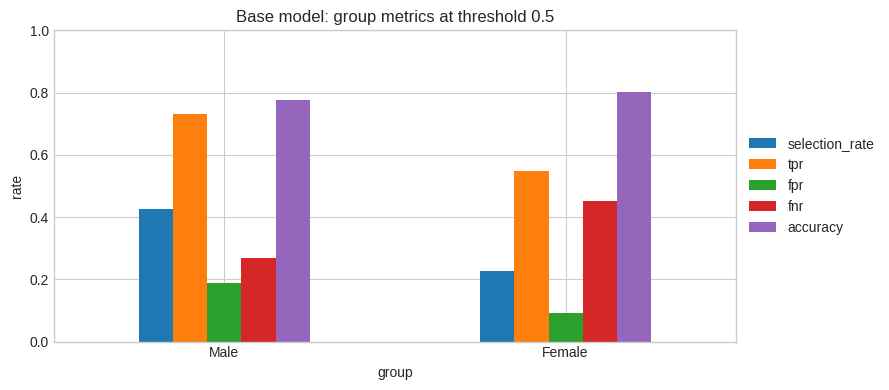

In [9]:
base_metrics_by_group = group_metric_table(acs_test_df, base_probs, threshold=0.5)
display(compact_group_table(base_metrics_by_group))
plot_group_metric_bars(base_metrics_by_group, "Base model: group metrics at threshold 0.5")

In [10]:
base_fairness_gaps = fairness_gaps(base_metrics_by_group)
display(compact_gap_table(base_fairness_gaps, "base_model_gap"))

,base_model_gap
demographic_parity_gap,0.1986
equal_opportunity_gap,0.1825
equalized_odds_gap,0.2794


### Analysis Question 1

**Base model:** Which group is disadvantaged by the base model? Use selection rate, TPR, FPR, or FNR to justify your answer.

<div dir="rtl" style="text-align: right;">

پاسخ:

<br> <br><br>
گروه Female توسط مدل پایه در وضعیت نامطلوب‌تری قرار گرفته است. مقدار selection rate برای گروه Male برابر با 0.4255 است، در حالی که این مقدار برای گروه Female فقط 0.2269 است. این یعنی مدل مردان را بسیار بیشتر از زنان به‌عنوان افراد دارای درآمد بالای 50K پیش‌بینی کرده است.

همچنین مقدار TPR برای گروه Male برابر با 0.7313 و برای گروه Female برابر با 0.5487 است. بنابراین در میان افرادی که واقعاً درآمد بالای 50K دارند، مدل مردان را بهتر از زنان تشخیص داده است.

مقدار FNR نیز این نتیجه را تأیید می‌کند. FNR برای Female برابر با 0.4513 است، اما برای Male برابر با 0.2687 است. یعنی مدل درصد بیشتری از زنان واقعاً مثبت را به اشتباه منفی تشخیص داده است. بنابراین با وجود اینکه accuracy گروه Female کمی بالاتر است، معیارهای selection rate، TPR و FNR نشان می‌دهند که گروه Female توسط مدل پایه disadvantage شده است.
</div>

### Analysis Question 2

**Fairness criteria:** Does the base model violate demographic parity, equal opportunity, and equalized odds? Which violation is largest?

<div dir="rtl" style="text-align: right;">

پاسخ:

<br><br><br>
بله، مدل پایه هر سه معیار عدالت را نقض کرده است. این مدل demographic parity را نقض می‌کند، زیرا selection rate دو گروه با هم اختلاف زیادی دارد. مقدار selection rate برای Male برابر با 0.4255 و برای Female برابر با 0.2269 است، که باعث ایجاد demographic parity gap برابر با 0.1986 شده است.

مدل همچنین equal opportunity را نقض می‌کند، زیرا مقدار TPR برای دو گروه متفاوت است. TPR برای Male برابر با 0.7313 و برای Female برابر با 0.5487 است. بنابراین equal opportunity gap برابر با 0.1825 به دست آمده است.

مدل equalized odds را نیز نقض می‌کند، زیرا هم TPR و هم FPR بین دو گروه متفاوت هستند. مقدار equalized odds gap برابر با 0.2794 است که بزرگ‌ترین شکاف عدالت در بین معیارهای گزارش‌شده است. بنابراین بزرگ‌ترین نقض عدالت مربوط به equalized odds است.
</div>

## Create Positive Group Subsets

For an FNR/equal-opportunity intervention, we focus on positively labeled examples. These are the examples that can become false negatives.

In [11]:
sensitive_group_pos = acs_train_df[
    (acs_train_df[SENSITIVE_ATTRIBUTE_KEY] == 2.0) &
    (acs_train_df[LABEL_KEY] == 1)
]

non_sensitive_group_pos = acs_train_df[
    (acs_train_df[SENSITIVE_ATTRIBUTE_KEY] == 1.0) &
    (acs_train_df[LABEL_KEY] == 1)
]

subset_counts = pd.DataFrame({
    "subset": ["positive Female", "positive Male"],
    "rows": [len(sensitive_group_pos), len(non_sensitive_group_pos)],
})
display(subset_counts)

,subset,rows
0,positive Female,13544
1,positive Male,21947


## Part 2: In-Processing with MinDiff / MMD

Complete the MinDiff-style regularizer below.

We use MMD with an RBF/Gaussian kernel:

$$
\mathrm{MMD}^2(X,Y)=\frac{1}{m^2}\sum_{i,j} k(x_i,x_j)+\frac{1}{n^2}\sum_{i,j} k(y_i,y_j)-\frac{2}{mn}\sum_{i,j} k(x_i,y_j)
$$

$$
k(x,y)=\exp\left(-\frac{\lVert x-y\rVert^2}{2\sigma^2}\right)
$$

To target FNR / equal opportunity, compare score distributions for positively labeled female and male examples.

In [12]:
def dataframe_to_tensor_dataset(dataframe):
    x_raw = dataframe[FEATURE_KEYS].astype("float32").to_numpy()
    y = dataframe[LABEL_KEY].astype("float32").to_numpy().reshape(-1, 1)
    x = (x_raw - x_mean) / x_std
    return TensorDataset(torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32))


def infinite_loader(dataset, batch_size):
    while True:
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
        for batch in loader:
            yield batch


def rbf_kernel(x, y, sigma=0.1):
    x = x.reshape(-1, 1)
    y = y.reshape(-1, 1)

    # Pairwise squared distance between all scores in x and y.
    # x shape: [m, 1]
    # y.T shape: [1, n]
    # result shape: [m, n]
    squared_distance = (x - y.T) ** 2

    # RBF / Gaussian kernel:
    # k(x, y) = exp(- ||x-y||^2 / (2 sigma^2))
    kernel_matrix = torch.exp(
        -squared_distance / (2 * sigma ** 2)
    )

    return kernel_matrix


def min_diff_regularizer(sensitive_scores, nonsensitive_scores, sigma=0.1):
    # sensitive_scores: scores for positive Female examples
    # nonsensitive_scores: scores for positive Male examples

    k_xx = rbf_kernel(
        sensitive_scores,
        sensitive_scores,
        sigma=sigma
    )

    k_yy = rbf_kernel(
        nonsensitive_scores,
        nonsensitive_scores,
        sigma=sigma
    )

    k_xy = rbf_kernel(
        sensitive_scores,
        nonsensitive_scores,
        sigma=sigma
    )

    # MMD^2 = mean(k_xx) + mean(k_yy) - 2 mean(k_xy)
    mmd_squared = k_xx.mean() + k_yy.mean() - 2.0 * k_xy.mean()

    # Numerical safety: MMD^2 should be non-negative, but small negative values
    # can appear due to floating point precision.
    mmd_squared = torch.clamp(mmd_squared, min=0.0)

    return mmd_squared


def train_with_mindiff(
    model,
    train_loader,
    sensitive_pos_df,
    nonsensitive_pos_df,
    min_diff_batch_size=128,
    epochs=5,
    learning_rate=5e-4,
    min_diff_weight=2.0,
    kernel_sigma=0.1,
):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    bce = nn.BCEWithLogitsLoss()

    sensitive_iter = infinite_loader(
        dataframe_to_tensor_dataset(sensitive_pos_df),
        min_diff_batch_size
    )

    nonsensitive_iter = infinite_loader(
        dataframe_to_tensor_dataset(nonsensitive_pos_df),
        min_diff_batch_size
    )

    history_rows = []

    for epoch in range(1, epochs + 1):
        model.train()

        total_losses = []
        task_losses = []
        penalty_losses = []

        for xb, yb in train_loader:
            xs, _ = next(sensitive_iter)
            xn, _ = next(nonsensitive_iter)

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            xs = xs.to(DEVICE)
            xn = xn.to(DEVICE)

            optimizer.zero_grad()

            # Main classification loss on the normal training batch
            logits = model(xb)
            task_loss = bce(logits, yb)

            # Scores for positive Female and positive Male examples
            sensitive_scores = torch.sigmoid(model(xs))
            nonsensitive_scores = torch.sigmoid(model(xn))

            # MinDiff / MMD penalty
            penalty = min_diff_regularizer(
                sensitive_scores,
                nonsensitive_scores,
                sigma=kernel_sigma
            )

            # Total loss = classification loss + lambda * MinDiff penalty
            total_loss = task_loss + min_diff_weight * penalty

            total_loss.backward()
            optimizer.step()

            total_losses.append(float(total_loss.detach().cpu()))
            task_losses.append(float(task_loss.detach().cpu()))
            penalty_losses.append(float(penalty.detach().cpu()))

        history_rows.append({
            "epoch": epoch,
            "total_loss": np.mean(total_losses),
            "task_loss": np.mean(task_losses),
            "mmd_penalty": np.mean(penalty_losses),
        })

    return model, pd.DataFrame(history_rows).set_index("epoch")

## Train the Remediated Model

Start from the base model weights and continue training with the MMD penalty.

In [13]:
min_diff_model = IncomeMLP(n_features=len(FEATURE_KEYS)).to(DEVICE)
min_diff_model.load_state_dict(base_model.state_dict())

min_diff_model, min_diff_history_df = train_with_mindiff(
    model=min_diff_model,
    train_loader=train_loader,
    sensitive_pos_df=sensitive_group_pos,
    nonsensitive_pos_df=non_sensitive_group_pos,
    min_diff_batch_size=128,
    epochs=5,
    learning_rate=5e-4,
    min_diff_weight=2.0,
    kernel_sigma=0.1,
)

display(min_diff_history_df.round(4))

,total_loss,task_loss,mmd_penalty
epoch,,,
1,0.4717,0.4417,0.0150
2,0.4638,0.4416,0.0111
3,0.4660,0.4417,0.0121
4,0.4640,0.4410,0.0115
5,0.4655,0.4408,0.0124


## Evaluate the Remediated Model

In [14]:
min_diff_probs = predict_proba(min_diff_model, x_test_t)
min_diff_pred = (min_diff_probs >= 0.5).astype(int)
min_diff_eval = pd.Series({
    "loss": float(nn.BCEWithLogitsLoss()(min_diff_model(x_test_t.to(DEVICE)), y_test_t.to(DEVICE)).detach().cpu()),
    "accuracy": float((min_diff_pred == y_test.reshape(-1).astype(int)).mean()),
}, name="mindiff_style_model")

display(pd.concat([base_eval, min_diff_eval], axis=1).round(4))

,base_model,mindiff_style_model
loss,0.4394,0.4427
accuracy,0.7885,0.7851


,group,n,base_rate,selection_rate,tpr,fpr,fnr,accuracy
0,Male,12399,0.4358,0.3925,0.6894,0.1631,0.3106,0.7726
1,Female,11601,0.2945,0.3056,0.6766,0.1507,0.3234,0.7985


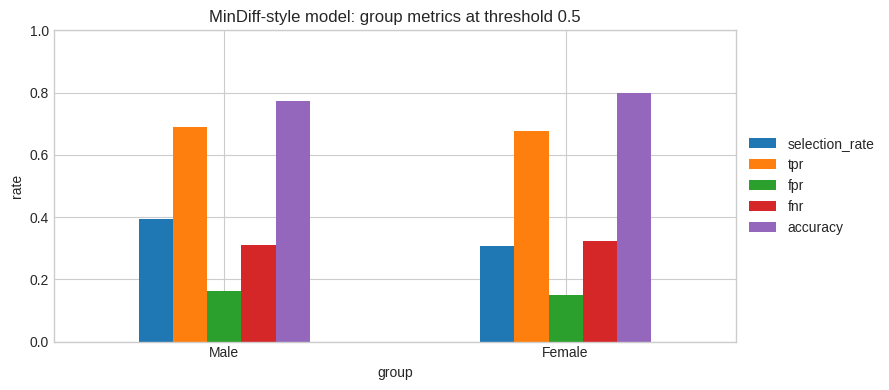

In [15]:
min_diff_metrics_by_group = group_metric_table(acs_test_df, min_diff_probs, threshold=0.5)
display(compact_group_table(min_diff_metrics_by_group))
plot_group_metric_bars(min_diff_metrics_by_group, "MinDiff-style model: group metrics at threshold 0.5")

In [16]:
min_diff_fairness_gaps = fairness_gaps(min_diff_metrics_by_group)
display(compact_gap_table(min_diff_fairness_gaps, "mindiff_style_gap"))

,mindiff_style_gap
demographic_parity_gap,0.0869
equal_opportunity_gap,0.0128
equalized_odds_gap,0.0252


## Compare Results

,metric,base_model,mindiff_style_model,change
0,demographic_parity_gap,0.1986,0.0869,-0.1118
1,equal_opportunity_gap,0.1825,0.0128,-0.1697
2,equalized_odds_gap,0.2794,0.0252,-0.2542


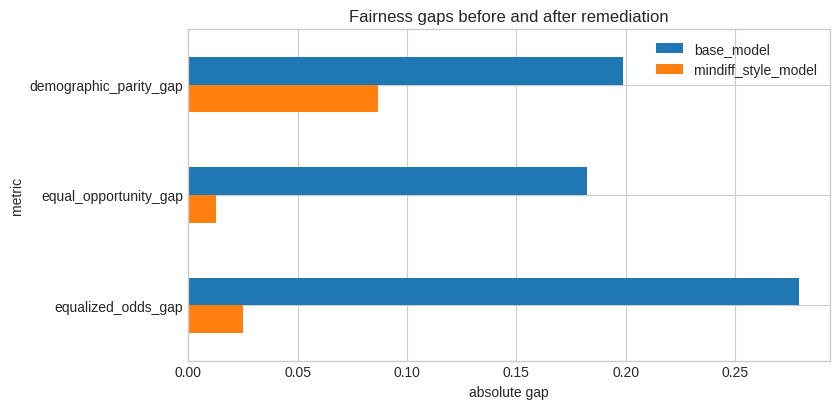

In [17]:
comparison = pd.DataFrame({
    "metric": [
        "demographic_parity_gap",
        "equal_opportunity_gap",
        "equalized_odds_gap",
    ],
    "base_model": [
        base_fairness_gaps["demographic_parity_gap"],
        base_fairness_gaps["equal_opportunity_gap"],
        base_fairness_gaps["equalized_odds_gap"],
    ],
    "mindiff_style_model": [
        min_diff_fairness_gaps["demographic_parity_gap"],
        min_diff_fairness_gaps["equal_opportunity_gap"],
        min_diff_fairness_gaps["equalized_odds_gap"],
    ],
})
comparison["change"] = comparison["mindiff_style_model"] - comparison["base_model"]

display(comparison.round(4))
plot_gap_comparison(comparison)

In [ ]:
base_group_view = compact_group_table(base_metrics_by_group).assign(model="Base")
mindiff_group_view = compact_group_table(min_diff_metrics_by_group).assign(model="MinDiff-style")
combined_group_view = pd.concat([base_group_view, mindiff_group_view], ignore_index=True)
combined_group_view = combined_group_view[["model", "group", "selection_rate", "tpr", "fpr", "fnr", "accuracy"]]
display(combined_group_view.round(4))

### Analysis Question 3

**MinDiff effect:** After MinDiff training, which fairness gaps improve? Did this improvement come with an accuracy cost?

<div dir="rtl" style="text-align: right;">

پاسخ:

<br><br><br>
پس از اعمال روش MinDiff-style regularization، هر سه شکاف عدالت بهبود پیدا کردند. مقدار demographic parity gap از 0.1986 به 0.0869 کاهش یافت. همچنین equal opportunity gap از 0.1825 به 0.0128 رسید و equalized odds gap نیز از 0.2794 به 0.0252 کاهش پیدا کرد.

بیشترین بهبود مربوط به equal opportunity و equalized odds بود. این نتیجه منطقی است، زیرا جریمه MinDiff روی نمونه‌های دارای برچسب مثبت از دو گروه Female و Male اعمال شده بود. بنابراین این روش مستقیماً روی نمونه‌هایی اثر می‌گذارد که ممکن است به اشتباه منفی تشخیص داده شوند و باعث افزایش FNR شوند.

از نظر دقت، افت عملکرد بسیار کم بود. دقت گروه Male از 0.7760 به 0.7726 کاهش یافت و دقت گروه Female نیز از 0.8018 به 0.7985 رسید. بنابراین می‌توان گفت MinDiff توانست عدالت مدل را به شکل قابل توجهی بهتر کند، در حالی که دقت مدل تقریباً حفظ شد.
</div>

### Analysis Question 4

**Trade-off:** Did MinDiff improve all fairness metrics equally, or did some metrics improve more than others?

<div dir="rtl" style="text-align: right;">

پاسخ:

<br><br><br>
روش MinDiff همه معیارهای عدالت را بهبود داد، اما این بهبود برای همه معیارها یکسان نبود. بیشترین بهبود در equal opportunity gap و equalized odds gap مشاهده شد. مقدار equal opportunity gap از 0.1825 به 0.0128 کاهش یافت و equalized odds gap نیز از 0.2794 به 0.0252 رسید.

این رفتار با هدف طراحی MinDiff سازگار است. در این تمرین، جریمه MinDiff روی نمونه‌های مثبت واقعی از دو گروه Female و Male اعمال شد. به همین دلیل مدل مجبور شد برای افراد واقعاً مثبت در دو گروه، scoreهای مشابه‌تری تولید کند. در نتیجه معیارهایی مثل TPR و FNR که مستقیماً به نمونه‌های مثبت مربوط هستند، بیشتر بهبود پیدا کردند.

در مقابل، demographic parity gap نیز بهتر شد و از 0.1986 به 0.0869 کاهش یافت، اما این معیار هدف مستقیم MinDiff نبود. بنابراین می‌توان نتیجه گرفت که MinDiff بیشتر معیارهای مرتبط با equal opportunity را بهبود داده و در کنار آن باعث بهبود نسبی demographic parity نیز شده است.
</div>

## Part 3: Group-Specific Thresholds (Post-Processing)

So far, both models used one global rule:

$$
\hat{Y}=1 \quad \text{if score} \ge 0.5
$$

Post-processing keeps the trained model fixed and only changes the final decision rule. Here we allow one threshold for male examples and one threshold for female examples:

$$
\hat{Y}=1 \quad \text{if score} \ge t_{Male} \quad \text{for male examples}
$$

$$
\hat{Y}=1 \quad \text{if score} \ge t_{Female} \quad \text{for female examples}
$$

Lowering a group's threshold usually increases its selection rate and TPR, but can also increase its FPR. Your goal is to see how threshold choices can target different fairness definitions.

### Step 3.1: Apply One Pair of Group Thresholds

Complete the function below. It takes two thresholds:

```python
male_threshold = 0.55
female_threshold = 0.45
```

This means: use threshold `0.55` for male examples and `0.45` for female examples. This step only creates predictions; the next step will evaluate them.

In [18]:
def predict_with_group_thresholds(dataframe, probabilities, male_threshold=0.5, female_threshold=0.5):
    probabilities = as_1d(probabilities)
    group_values = dataframe[SENSITIVE_ATTRIBUTE_KEY].to_numpy()
    y_pred = np.zeros(len(probabilities), dtype=int)

    male_mask = group_values == 1.0
    female_mask = group_values == 2.0

    # Predict positives for male examples using male_threshold.
    y_pred[male_mask] = (
        probabilities[male_mask] >= male_threshold
    ).astype(int)

    # Predict positives for female examples using female_threshold.
    y_pred[female_mask] = (
        probabilities[female_mask] >= female_threshold
    ).astype(int)

    return y_pred


# Try the standard global threshold first: both groups use 0.5.
example_pred = predict_with_group_thresholds(
    acs_test_df,
    base_probs,
    male_threshold=0.5,
    female_threshold=0.5,
)

print("Number of predicted positives:", int(example_pred.sum()))
print("Prediction vector shape:", example_pred.shape)

Number of predicted positives: 7908
Prediction vector shape: (24000,)


### Step 3.2: Evaluate a Threshold Pair

Now complete a helper that evaluates one `(male_threshold, female_threshold)` pair.

It should return:

- the threshold values,
- accuracy,
- demographic parity gap,
- equal opportunity gap,
- equalized odds gap.

In [19]:
def accuracy_from_predictions(dataframe, y_pred):
    y_true = dataframe[LABEL_KEY].to_numpy().astype(int)
    y_pred = as_1d(y_pred).astype(int)

    # Return the fraction of correct predictions.
    return float((y_true == y_pred).mean())


def evaluate_threshold_pair(dataframe, probabilities, male_threshold, female_threshold):
    y_pred = predict_with_group_thresholds(
        dataframe,
        probabilities,
        male_threshold=male_threshold,
        female_threshold=female_threshold,
    )

    metric_table = metric_table_from_predictions(dataframe, y_pred)
    gaps = fairness_gaps(metric_table)
    accuracy = accuracy_from_predictions(dataframe, y_pred)

    return {
        "male_threshold": male_threshold,
        "female_threshold": female_threshold,
        "accuracy": accuracy,
        "demographic_parity_gap": gaps["demographic_parity_gap"],
        "equal_opportunity_gap": gaps["equal_opportunity_gap"],
        "equalized_odds_gap": gaps["equalized_odds_gap"],
    }


# Try one manual pair. What happens if we lower the female threshold?
evaluate_threshold_pair(
    acs_test_df,
    base_probs,
    male_threshold=0.5,
    female_threshold=0.4,
)

{'male_threshold': 0.5,
 'female_threshold': 0.4,
 'accuracy': 0.7862916666666667,
 'demographic_parity_gap': np.float64(0.1335605970876177),
 'equal_opportunity_gap': np.float64(0.07981177172568743),
 'equalized_odds_gap': np.float64(0.12734354103165027)}

### Step 3.3: Search Threshold Pairs

We now try many threshold pairs and choose the pair that best matches a fairness goal.

For example:

- To target **demographic parity**, choose the pair with the smallest `demographic_parity_gap`.
- To target **equal opportunity**, choose the pair with the smallest `equal_opportunity_gap`.
- To target **equalized odds**, choose the pair with the smallest `equalized_odds_gap`.

Important: we reject threshold pairs that reduce accuracy by more than `max_accuracy_drop`, because a trivial threshold can make a fairness gap small while producing a useless classifier.

In [20]:
def search_group_thresholds(dataframe, probabilities, goal, max_accuracy_drop=0.03):
    threshold_grid = np.round(np.linspace(0.05, 0.95, 19), 2)

    baseline = evaluate_threshold_pair(
        dataframe,
        probabilities,
        male_threshold=0.5,
        female_threshold=0.5,
    )

    min_allowed_accuracy = baseline["accuracy"] - max_accuracy_drop

    rows = []

    for male_threshold in threshold_grid:
        for female_threshold in threshold_grid:
            result = evaluate_threshold_pair(
                dataframe,
                probabilities,
                male_threshold=male_threshold,
                female_threshold=female_threshold,
            )

            # Skip threshold pairs whose accuracy is too low.
            if result["accuracy"] < min_allowed_accuracy:
                continue

            rows.append(result)

    search_results = pd.DataFrame(rows)

    if len(search_results) == 0:
        raise ValueError(
            "No threshold pair satisfied the accuracy constraint. "
            "Try increasing max_accuracy_drop."
        )

    # Sort by the chosen fairness goal first, then by accuracy descending.
    search_results = search_results.sort_values(
        by=[goal, "accuracy"],
        ascending=[True, False]
    ).reset_index(drop=True)

    return search_results


# Example: best base-model thresholds for equal opportunity.
base_equal_opportunity_search = search_group_thresholds(
    acs_test_df,
    base_probs,
    goal="equal_opportunity_gap",
)

base_equal_opportunity_search.head(10).round(4)

,male_threshold,female_threshold,accuracy,demographic_parity_gap,equal_opportunity_gap,equalized_odds_gap
0,0.75,0.60,0.7585,0.0580,0.0065,0.0090
1,0.40,0.25,0.7662,0.0943,0.0068,0.0281
2,0.70,0.55,0.7684,0.0679,0.0095,0.0170
3,0.60,0.40,0.7810,0.0562,0.0207,0.0326
4,0.45,0.30,0.7780,0.0989,0.0211,0.0422
5,0.65,0.50,0.7775,0.0793,0.0211,0.0311
6,0.55,0.35,0.7826,0.0572,0.0229,0.0376
7,0.50,0.35,0.7839,0.0964,0.0251,0.0428
8,0.50,0.30,0.7787,0.0537,0.0291,0.0492
9,0.65,0.45,0.7770,0.0482,0.0298,0.0426


### Step 3.4: Compare Post-Processing Goals

Complete the summary below for both the base model and the MinDiff-style model.

,model,method,male_threshold,female_threshold,accuracy,demographic_parity_gap,equal_opportunity_gap,equalized_odds_gap
0,Base,global 0.5,0.50,0.50,0.7885,0.1986,0.1825,0.2794
1,Base,target demographic parity,0.75,0.50,0.7618,0.0019,0.1068,0.1418
2,Base,target equal opportunity,0.75,0.60,0.7585,0.0580,0.0065,0.0090
3,Base,target equalized odds,0.75,0.60,0.7585,0.0580,0.0065,0.0090
4,MinDiff-style,global 0.5,0.50,0.50,0.7851,0.0869,0.0128,0.0252
5,MinDiff-style,target demographic parity,0.65,0.55,0.7693,0.0002,0.1035,0.1464
6,MinDiff-style,target equal opportunity,0.65,0.65,0.7704,0.0631,0.0005,0.0038
7,MinDiff-style,target equalized odds,0.70,0.70,0.7607,0.0565,0.0010,0.0024


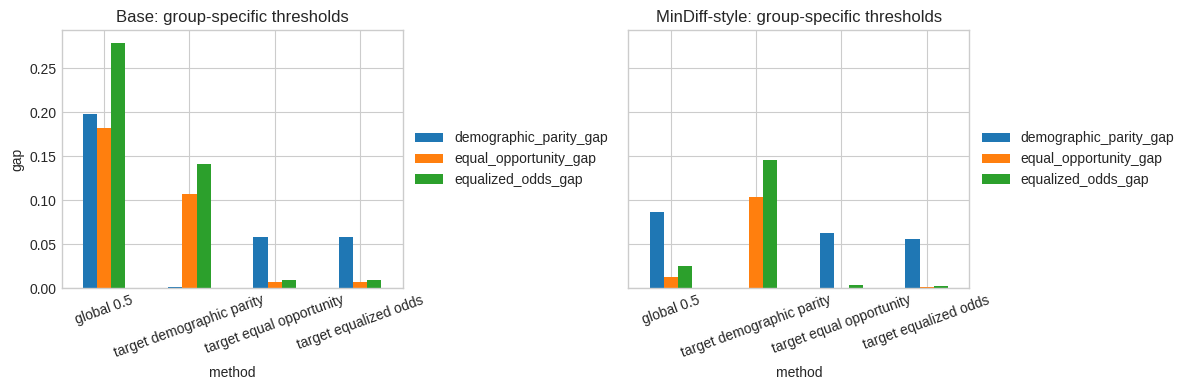

In [21]:
def best_threshold_row(model_name, method_name, probabilities, goal):
    if goal is None:
        result = evaluate_threshold_pair(
            acs_test_df,
            probabilities,
            male_threshold=0.5,
            female_threshold=0.5,
        )
    else:
        search_results = search_group_thresholds(
            acs_test_df,
            probabilities,
            goal=goal,
        )
        result = search_results.iloc[0].to_dict()

    result["model"] = model_name
    result["method"] = method_name

    return result


rows = []

for model_name, probabilities in [
    ("Base", base_probs),
    ("MinDiff-style", min_diff_probs),
]:
    rows.append(
        best_threshold_row(
            model_name,
            "global 0.5",
            probabilities,
            goal=None
        )
    )

    # Add a row targeting demographic parity.
    rows.append(
        best_threshold_row(
            model_name,
            "target demographic parity",
            probabilities,
            goal="demographic_parity_gap"
        )
    )

    # Add a row targeting equal opportunity.
    rows.append(
        best_threshold_row(
            model_name,
            "target equal opportunity",
            probabilities,
            goal="equal_opportunity_gap"
        )
    )

    # Add a row targeting equalized odds.
    rows.append(
        best_threshold_row(
            model_name,
            "target equalized odds",
            probabilities,
            goal="equalized_odds_gap"
        )
    )


threshold_method_summary = pd.DataFrame(rows)

summary_columns = [
    "model",
    "method",
    "male_threshold",
    "female_threshold",
    "accuracy",
    "demographic_parity_gap",
    "equal_opportunity_gap",
    "equalized_odds_gap",
]

display(threshold_method_summary[summary_columns].round(4))

plot_group_threshold_summary(
    threshold_method_summary.rename(columns={
        "male_threshold": "threshold_Male",
        "female_threshold": "threshold_Female",
    })
)

### Analysis Question 5

**Post-processing:** How do group-specific thresholds change the fairness gaps compared with the global `0.5` threshold?

<div dir="rtl" style="text-align: right;">

پاسخ:

<br><br><br>
Thresholdهای گروهی باعث کاهش قابل توجه شکاف‌های عدالت نسبت به threshold عمومی 0.5 شدند. در مدل پایه، threshold عمومی باعث ایجاد demographic parity gap برابر با 0.1986، equal opportunity gap برابر با 0.1825 و equalized odds gap برابر با 0.2794 شده بود.

وقتی thresholdها برای demographic parity بهینه شدند، demographic parity gap به 0.0019 کاهش یافت، اما equal opportunity gap و equalized odds gap همچنان نسبتاً بزرگ باقی ماندند. این نشان می‌دهد که بهینه کردن یک معیار عدالت الزاماً باعث بهبود همه معیارها نمی‌شود.

وقتی thresholdها برای equal opportunity و equalized odds بهینه شدند، شکاف‌های مربوط به فرصت برابر و خطاها بسیار کاهش یافتند. equal opportunity gap به 0.0065 و equalized odds gap به 0.0090 رسید. البته accuracy از 0.7885 به 0.7585 کاهش یافت. بنابراین thresholding گروهی عدالت را به شکل قابل توجهی بهتر کرد، اما با کمی افت دقت همراه بود.
</div>

### Analysis Question 6

**Post-processing comparison:** Does group-specific thresholding have a larger effect on the base model or on the MinDiff model? Explain using the before/after gaps and accuracy.

<div dir="rtl" style="text-align: right;">

پاسخ:

<br><br><br>
اثر thresholding روی مدل پایه از نظر مقدار کاهش شکاف‌ها بیشتر دیده می‌شود، زیرا مدل پایه در ابتدا شکاف‌های عدالت بزرگ‌تری داشت. برای مثال، equalized odds gap در مدل پایه از 0.2794 با threshold عمومی به 0.0090 پس از بهینه‌سازی thresholdها کاهش یافت.

مدل MinDiff-style از ابتدا با threshold عمومی عادلانه‌تر بود. مقدار equal opportunity gap آن فقط 0.0128 و equalized odds gap آن 0.0252 بود. پس از thresholding، این مقادیر حتی کمتر شدند؛ برای مثال equalized odds gap به 0.0024 رسید.

بنابراین thresholding هر دو مدل را بهتر کرد، اما بهبود مطلق آن برای مدل پایه بیشتر بود. در مدل MinDiff-style، thresholding بیشتر نقش fine-tuning داشت، چون بخش زیادی از شکاف‌های عدالت قبلاً در زمان آموزش با MinDiff کاهش یافته بود.
</div>

### Analysis Question 7

**Method comparison:** Compare MinDiff and group-specific thresholding. Which method gives the better fairness result, and which is easier to justify?

<div dir="rtl" style="text-align: right;">

پاسخ:

<br><br><br>
MinDiff و group-specific thresholding به دو روش متفاوت عدالت مدل را بهبود می‌دهند. MinDiff یک روش in-processing است، زیرا تابع هزینه مدل را هنگام آموزش تغییر می‌دهد و یک جمله regularization برای کاهش اختلاف بین گروه‌ها اضافه می‌کند. در این آزمایش، MinDiff توانست شکاف‌های عدالت را به شکل قابل توجهی کاهش دهد، در حالی که دقت مدل تقریباً حفظ شد. بنابراین MinDiff یک روش پایدار و قابل دفاع برای کاهش bias است.

در مقابل، group-specific thresholding یک روش post-processing است. این روش مدل را دوباره آموزش نمی‌دهد، بلکه فقط threshold تصمیم‌گیری را برای هر گروه جداگانه تنظیم می‌کند. این روش برای کاهش معیارهای خاصی مثل equal opportunity و equalized odds بسیار مؤثر بود، اما ممکن است باعث افت accuracy شود و همچنین ممکن است یک معیار عدالت را بهتر کند ولی معیارهای دیگر را به همان اندازه بهبود ندهد.

از نظر اخلاقی و کاربردی، MinDiff معمولاً قابل دفاع‌تر است، زیرا مدل در زمان آموزش یاد می‌گیرد scoreهای عادلانه‌تری تولید کند. اما thresholding گروهی در زمان تصمیم‌گیری مستقیماً از ویژگی حساس استفاده می‌کند و این موضوع ممکن است در بعضی کاربردها از نظر قانونی یا اخلاقی حساس باشد.

در مجموع، بهترین نتیجه زمانی به دست آمد که هر دو روش با هم استفاده شدند: ابتدا MinDiff شکاف‌های عدالت را در زمان آموزش کاهش داد و سپس thresholding شکاف‌های باقی‌مانده را کمتر کرد.
</div>

# Conclusion

This experiment demonstrated several approaches for improving fairness in machine learning models.

Key findings:

- The baseline model showed measurable group disparities.
- MinDiff-style regularization reduced fairness gaps while maintaining predictive performance.
- Group-specific thresholding provided another post-processing approach for controlling fairness objectives.

These experiments highlight the importance of evaluating machine learning systems beyond accuracy alone.